# Teaching a Computer to Predict Blood Sugar: First Attempt

We're trying to recreate part of a published study that built a tool to predict what
someone's blood sugar will be **1 hour from now**, using their recent glucose readings,
insulin doses, and meals.

The original study's clever idea: most prediction tools try to be right *on average*.
But being slightly off when blood sugar is normal isn't dangerous. Being off when it's
dangerously high or low is. So the researchers trained their model to care much more
about getting those risky moments right, even if that means being a little less
"perfectly average" the rest of the time.

This notebook is our **first, simplest attempt**. We are *not* doing that clever
"pay more attention to danger zones" part yet. We're just building and testing the
basic prediction tool first, to make sure it actually works, before adding the smarter
training trick on top.

**What this version does:** builds one predictor per person (25 people total), each one
looking only at that person's own recent glucose, insulin, and meal history, and reports
how far off its 1-hour-ahead guesses tend to be.

**What we're leaving out for now (coming in later versions):** the "pay more attention
to danger zones" trick, the automated trial-and-error search the original researchers
used to fine-tune it, a second and more complex model type, and extra scoring that looks
specifically at how often we'd miss a dangerous high or low rather than just the average
miss.

**Guesses we had to make:** the original paper didn't publish every exact setting it
used (exactly how far back the model looks, its internal size, how long it trains). We
picked reasonable values ourselves and note them along the way. This is a rough first
attempt, not an exact copy. If an exact copy is ever needed, the original authors
published their own code, linked at the bottom.


## 0. What is AZT1D, and can we trust it?

**What it is:** AZT1D is real-world data from 25 people with type 1 diabetes, each already
using an automated insulin delivery system: a continuous glucose monitor (Dexcom G6 Pro)
paired with an insulin pump (Tandem t:slim X2) that automatically adjusts insulin based on
glucose trends. For roughly a month per person, the system logged glucose every 5 minutes,
every insulin dose (background and meal-time), every meal's carb count, and what mode the
pump was in.

**How it was collected:** This isn't a lab experiment. It's real people living their
normal lives. Researchers at Mayo Clinic Arizona pulled the data straight off each
patient's pump and sensor during routine diabetes check-ups between December 2023 and
April 2024, with the patients' informed consent and approval from Mayo Clinic's ethics
review board. Nothing about how these 25 people ate, exercised, or dosed insulin was
changed for the study. The data is just what their devices already record as part of
everyday care.

**How much can we trust it?** A few things are reassuring: it comes from a named,
credentialed research team (Mayo Clinic and Arizona State University), it went through an
ethics review, and it's published openly (under a license that lets anyone use it as long
as the source is credited) on Mendeley Data, a recognized public repository for research
datasets. The paper describing it has also already been built on by follow-up research,
including the paper we're replicating in this notebook. It's still worth keeping its
limits in mind: it's brand new (published in 2025), it's just 25 people from one clinic,
and it skews older (patients ranged 27-80, averaging around 60). Whatever we find here
describes this specific group well, but shouldn't be assumed to hold for, say, children
or a different clinical population without checking.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from azt1d import loading, plotting, synthetic
from azt1d import reference as ref
from azt1d.glimmer import features as feat
from azt1d.glimmer import sequences as seq
from azt1d.glimmer.model import CNNLSTM, count_parameters
from azt1d.glimmer.train import train_subject_model, run_baseline_v0, get_device

plotting.apply_style()
pd.set_option("display.max_columns", None)


## 1. Getting the data ready

This loads everyone's glucose, insulin, and meal records: the real dataset if it has
arrived, otherwise a made-up stand-in with the same shape, so everything can be built and
tested before the real data shows up.


In [2]:
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
SYNTHETIC_DIR = PROCESSED_DIR / "synthetic"

has_real_data = loading.find_dataset_zip(RAW_DIR) is not None or bool(loading.discover_subject_files(RAW_DIR))

if has_real_data:
    print("Found real AZT1D data in data/raw/ -- loading it.")
    df = loading.load_real_dataset(RAW_DIR, PROCESSED_DIR)
    USING_SYNTHETIC = False
else:
    print("No real dataset found in data/raw/ yet -- using synthetic placeholder data.")
    if not any(SYNTHETIC_DIR.glob("*.csv")):
        synthetic.write_synthetic_csvs(SYNTHETIC_DIR)
    df = loading.load_all_subjects(SYNTHETIC_DIR)
    USING_SYNTHETIC = True

print(f"Loaded {len(df):,} rows across {df['subject_id'].nunique()} subjects.")


Found real AZT1D data in data/raw/ -- loading it.


Loaded 300,923 rows across 25 subjects.


## 2. Getting to know the data

Before building any predictor, let's actually look at what we're working with: what a
typical reading looks like, how the numbers are spread out, how glucose moves over time
and across the day, which things seem to move together, and where the odd or extreme
values are.


### What are we actually measuring?

- **Glucose (CGM):** a sensor worn under the skin measures blood sugar every 5 minutes,
  in mg/dL. Roughly 70-180 mg/dL is the everyday target range: below 70 is dangerously low
  (hypoglycemia), above 180 is too high (hyperglycemia).
- **Background ("basal") insulin:** a small, steady trickle of insulin the pump delivers
  around the clock just to keep blood sugar level, measured in units per hour (U/hr).
- **Meal-time ("bolus") insulin:** a bigger, one-time dose given either to cover a meal or
  to bring down a high reading, measured in units (U). The data separates how much of each
  dose was for food versus for correcting a high.
- **Carbs:** grams of carbohydrate eaten at a logged meal. Carbs are what push blood
  sugar up, so insulin doses are usually sized to roughly match them.
- **Device mode:** whether the insulin pump was running its normal settings, or had been
  switched to a sleep or exercise setting (both change how aggressively it adjusts
  insulin behind the scenes). Not used as a model input in this version, but it's part of
  the raw data.

Everything below is built from the first four. Device mode gets its own look in the
separate exploration notebook.


In [3]:
print(f"{len(df):,} total 5-minute readings, across {df['subject_id'].nunique()} people")
print(f"Date range: {df[ref.EVENT_DATETIME].min().date()} to {df[ref.EVENT_DATETIME].max().date()}")
print()
df[[ref.CGM, ref.BASAL, ref.TOTAL_BOLUS_INSULIN_DELIVERED, ref.CARB_SIZE]].describe().round(2)


300,923 total 5-minute readings, across 25 people
Date range: 2023-12-08 to 2024-04-07



,CGM,Basal,TotalBolusInsulinDelivered,CarbSize
count,300923.00,300923.00,300923.00,300923.00
mean,146.45,0.97,0.11,0.41
std,47.55,1.10,1.00,4.26
min,40.00,0.00,0.00,0.00
25%,114.00,0.36,0.00,0.00
50%,138.00,0.67,0.00,0.00
75%,171.00,1.21,0.00,0.00
max,400.00,13.00,25.00,120.00


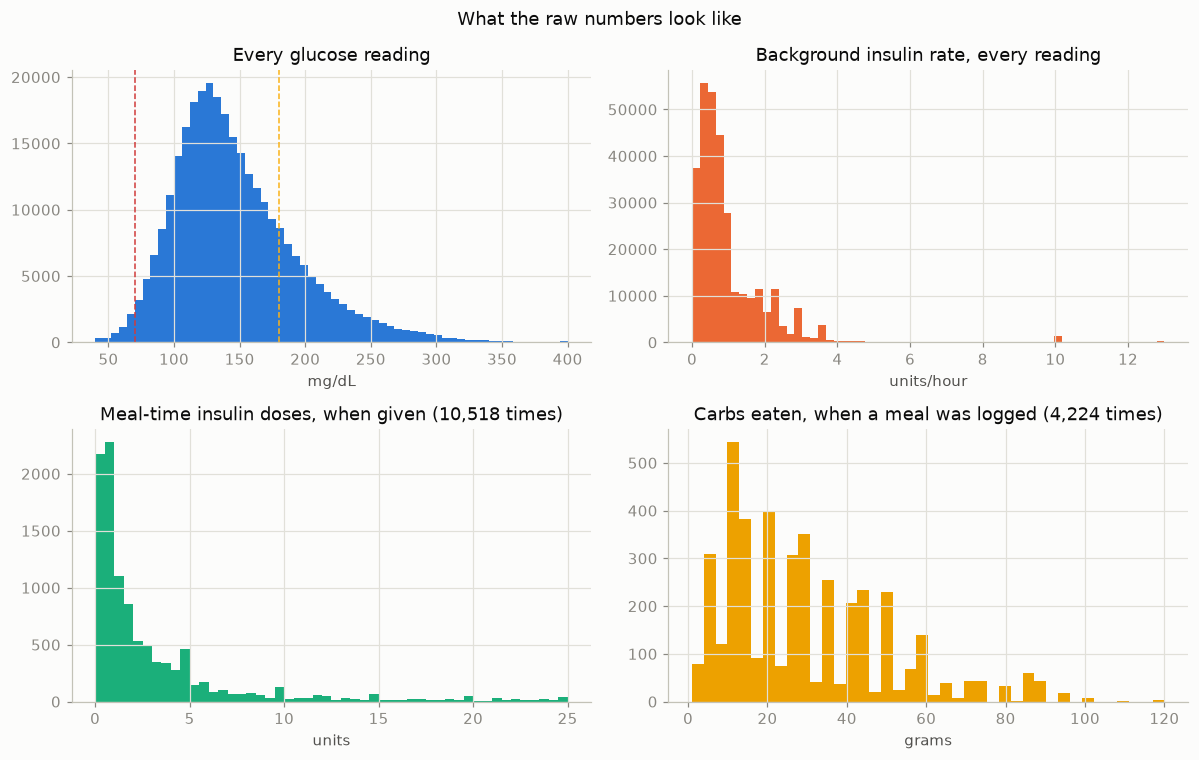

In [4]:
bolus_doses = df.loc[df[ref.TOTAL_BOLUS_INSULIN_DELIVERED] > 0, ref.TOTAL_BOLUS_INSULIN_DELIVERED]
carb_sizes = df.loc[df[ref.CARB_SIZE] > 0, ref.CARB_SIZE]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

axes[0, 0].hist(df[ref.CGM], bins=60, color=plotting.CATEGORICAL[0])
axes[0, 0].axvline(ref.HYPO_THRESHOLD, color=plotting.GLUCOSE_BAND_COLORS["hypo"], linestyle="--", linewidth=1)
axes[0, 0].axvline(ref.HYPER_THRESHOLD, color=plotting.GLUCOSE_BAND_COLORS["hyper"], linestyle="--", linewidth=1)
axes[0, 0].set_title("Every glucose reading")
axes[0, 0].set_xlabel("mg/dL")

axes[0, 1].hist(df[ref.BASAL], bins=60, color=plotting.CATEGORICAL[1])
axes[0, 1].set_title("Background insulin rate, every reading")
axes[0, 1].set_xlabel("units/hour")

axes[1, 0].hist(bolus_doses, bins=50, color=plotting.CATEGORICAL[2])
axes[1, 0].set_title(f"Meal-time insulin doses, when given ({len(bolus_doses):,} times)")
axes[1, 0].set_xlabel("units")

axes[1, 1].hist(carb_sizes, bins=40, color=plotting.CATEGORICAL[3])
axes[1, 1].set_title(f"Carbs eaten, when a meal was logged ({len(carb_sizes):,} times)")
axes[1, 1].set_xlabel("grams")

fig.suptitle("What the raw numbers look like")
fig.tight_layout()
plt.show()


**Observation:** Glucose readings are not symmetric. There is a long tail toward high
values, not low ones. This makes sense for two reasons: patients and their pumps actively
try to avoid going low, since the immediate risks are more acute there, and glucose cannot
go below zero, so the low end has a hard floor the high end does not have.


### How does glucose move, and what tracks with what?

First, one person's entire record over time. Then everyone's average glucose by hour of
day, to see if there's a shared daily rhythm. Then whether meal size, insulin, and glucose
seem to move together.


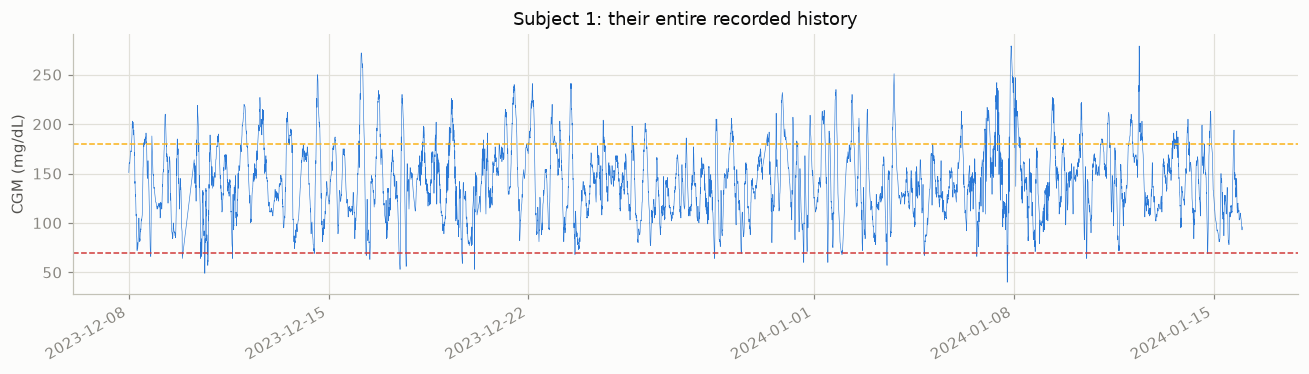

In [5]:
example_full = df[df["subject_id"] == df["subject_id"].iloc[0]].sort_values(ref.EVENT_DATETIME)

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(example_full[ref.EVENT_DATETIME], example_full[ref.CGM], color=plotting.CATEGORICAL[0], linewidth=0.4)
ax.axhline(ref.HYPO_THRESHOLD, color=plotting.GLUCOSE_BAND_COLORS["hypo"], linestyle="--", linewidth=1)
ax.axhline(ref.HYPER_THRESHOLD, color=plotting.GLUCOSE_BAND_COLORS["hyper"], linestyle="--", linewidth=1)
ax.set_ylabel("CGM (mg/dL)")
ax.set_title(f"Subject {int(example_full['subject_id'].iloc[0])}: their entire recorded history")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


**Observation:** The dashed lines mark the danger thresholds, low at the bottom and high
at the top. Subject 1 spent about 14% of their time above the high threshold and only
about 1% below the low threshold. That matches the whole cohort: 20% hyper versus 2%
hypo. Patients run high far more often than they run low.


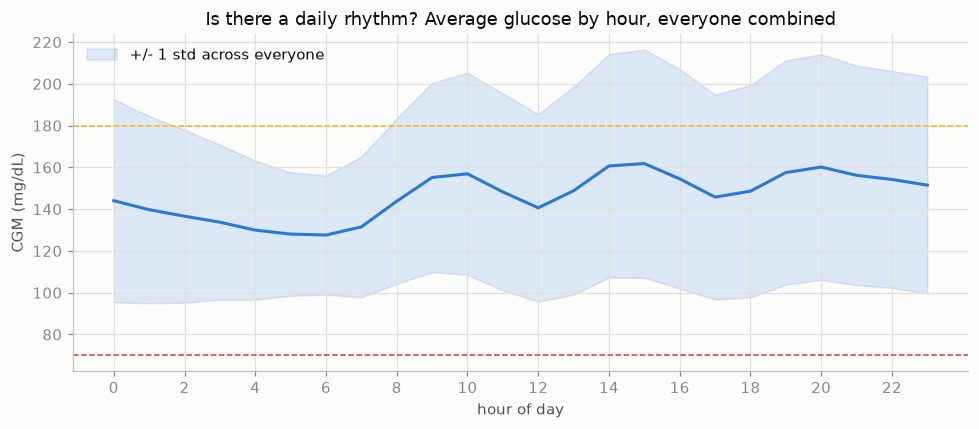

In [6]:
hourly = df.groupby(df[ref.EVENT_DATETIME].dt.hour)[ref.CGM].agg(["mean", "std"])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(hourly.index, hourly["mean"], color=plotting.CATEGORICAL[0], linewidth=2)
ax.fill_between(hourly.index, hourly["mean"] - hourly["std"], hourly["mean"] + hourly["std"],
                 color=plotting.CATEGORICAL[0], alpha=0.15, label="+/- 1 std across everyone")
ax.axhline(ref.HYPO_THRESHOLD, color=plotting.GLUCOSE_BAND_COLORS["hypo"], linestyle="--", linewidth=1)
ax.axhline(ref.HYPER_THRESHOLD, color=plotting.GLUCOSE_BAND_COLORS["hyper"], linestyle="--", linewidth=1)
ax.set_xlabel("hour of day")
ax.set_ylabel("CGM (mg/dL)")
ax.set_title("Is there a daily rhythm? Average glucose by hour, everyone combined")
ax.set_xticks(range(0, 24, 2))
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


**Observation:** This pattern is probably driven by mealtimes, not a body clock. Worth
checking directly: does it flatten out if we remove the meal-related rises, or is there a
real time-of-day effect underneath?


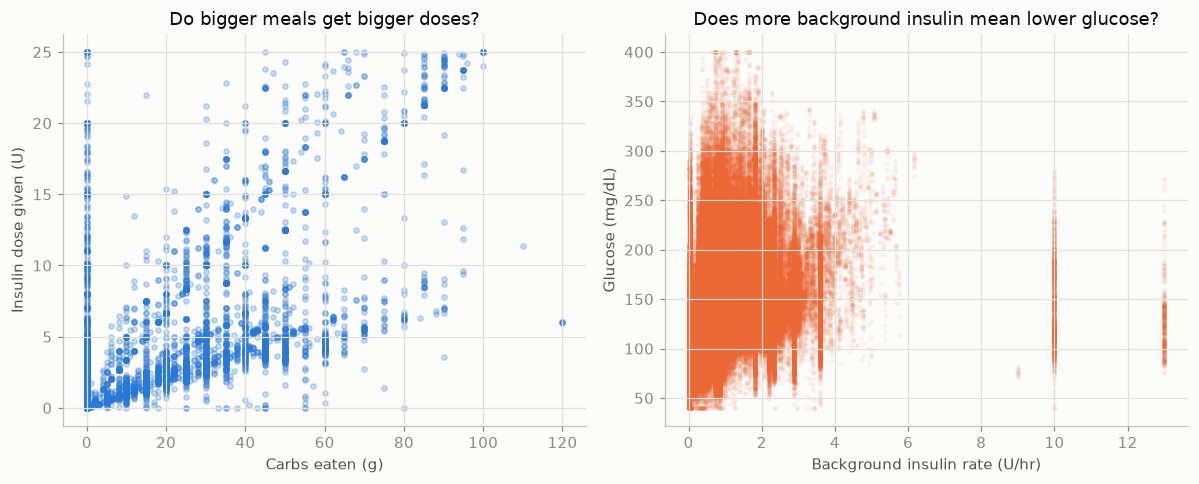

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

meal_events = df[(df[ref.CARB_SIZE] > 0) | (df[ref.TOTAL_BOLUS_INSULIN_DELIVERED] > 0)]
axes[0].scatter(meal_events[ref.CARB_SIZE], meal_events[ref.TOTAL_BOLUS_INSULIN_DELIVERED],
                alpha=0.25, s=12, color=plotting.CATEGORICAL[0])
axes[0].set_xlabel("Carbs eaten (g)")
axes[0].set_ylabel("Insulin dose given (U)")
axes[0].set_title("Do bigger meals get bigger doses?")

axes[1].scatter(df[ref.BASAL], df[ref.CGM], alpha=0.05, s=5, color=plotting.CATEGORICAL[1])
axes[1].set_xlabel("Background insulin rate (U/hr)")
axes[1].set_ylabel("Glucose (mg/dL)")
axes[1].set_title("Does more background insulin mean lower glucose?")

fig.tight_layout()
plt.show()


**Observation:** The carbs-to-dose relationship (0.76 correlation) is a behavioral one,
not a biological one. Someone, or their pump, is choosing the dose based on the meal, so
bigger meals getting bigger doses just confirms people are dosing sensibly. Background
insulin has almost no correlation with glucose (0.16). That is probably because it is
already tuned per person to hold them in range, so any real effect gets washed out once
everyone is pooled together.


How strongly each pair moves together (-1 = opposite, 0 = no link, +1 = together):


,Glucose,Background insulin,Meal insulin,Carbs
Glucose,1.00,0.16,0.05,0.01
Background insulin,0.16,1.00,0.04,0.00
Meal insulin,0.05,0.04,1.00,0.76
Carbs,0.01,0.00,0.76,1.00


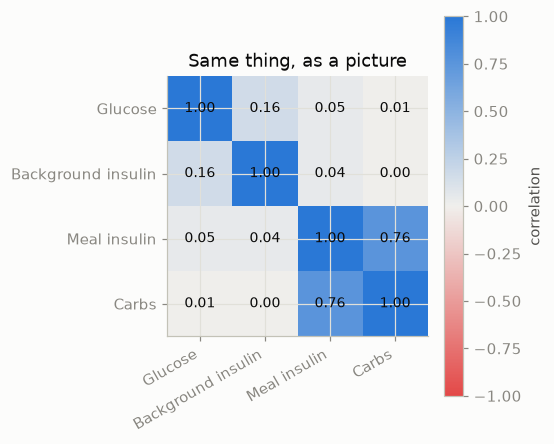

In [8]:
from matplotlib.colors import LinearSegmentedColormap

corr_cols = [ref.CGM, ref.BASAL, ref.TOTAL_BOLUS_INSULIN_DELIVERED, ref.CARB_SIZE]
corr_labels = ["Glucose", "Background insulin", "Meal insulin", "Carbs"]
corr = df[corr_cols].corr()

print("How strongly each pair moves together (-1 = opposite, 0 = no link, +1 = together):")
display(corr.set_axis(corr_labels, axis=0).set_axis(corr_labels, axis=1).round(2))

diverging_cmap = LinearSegmentedColormap.from_list("diverging", ["#e34948", "#f0efec", "#2a78d6"])
fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(corr, cmap=diverging_cmap, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_labels)), corr_labels, rotation=30, ha="right")
ax.set_yticks(range(len(corr_labels)), corr_labels)
for i in range(len(corr_labels)):
    for j in range(len(corr_labels)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax, label="correlation")
ax.set_title("Same thing, as a picture")
fig.tight_layout()
plt.show()


**Observation:** Nothing else in the table stands out. The only real number is meal
insulin with carbs (0.76), which is the same behavioral pattern already covered above.


### Where are the odd, extreme readings?

A box plot draws a box around the "typical middle" of the data and shows anything far
outside it as individual dots. It's a quick way to spot data errors or genuinely unusual
moments. Some obvious data errors (like an impossible insulin reading) were already
cleaned up before this notebook even sees the data. This shows what's left.


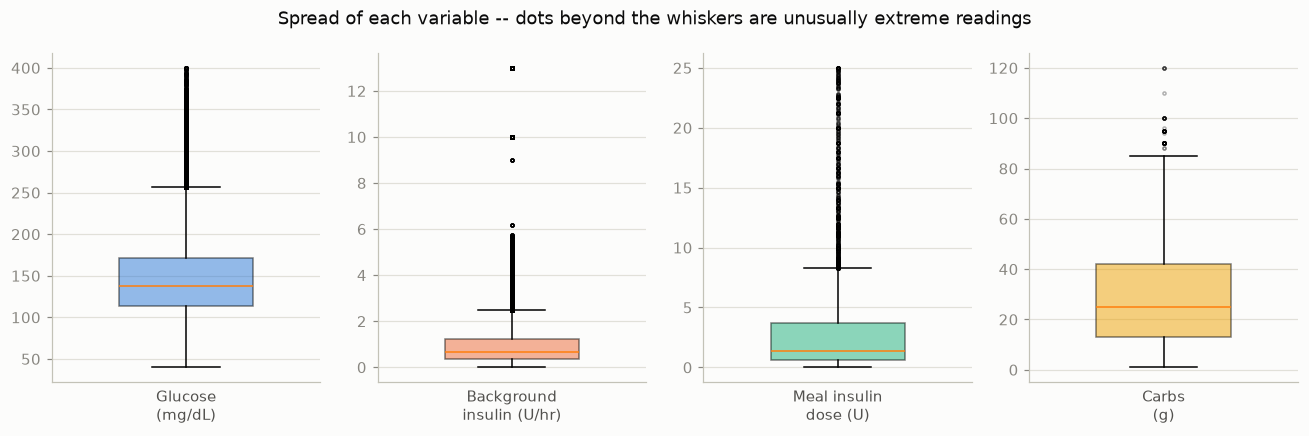

Readings far outside the typical range for each variable:
  Glucose:             9,318 of 300,923 readings
  Background insulin: 20,555 of 300,923 readings
  Meal insulin dose:     991 of  10,518 events
  Carbs eaten:            75 of   4,224 events


In [9]:
def typical_range_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((series < lower) | (series > upper)).sum())


fig, axes = plt.subplots(1, 4, figsize=(12, 4))
box_data = [
    (df[ref.CGM], "Glucose\n(mg/dL)", plotting.CATEGORICAL[0]),
    (df[ref.BASAL], "Background\ninsulin (U/hr)", plotting.CATEGORICAL[1]),
    (bolus_doses, "Meal insulin\ndose (U)", plotting.CATEGORICAL[2]),
    (carb_sizes, "Carbs\n(g)", plotting.CATEGORICAL[3]),
]
for ax, (data, label, color) in zip(axes, box_data):
    bp = ax.boxplot(data, patch_artist=True, widths=0.5, flierprops=dict(marker="o", markersize=2, alpha=0.3))
    bp["boxes"][0].set_facecolor(color)
    bp["boxes"][0].set_alpha(0.5)
    ax.set_xticks([])
    ax.set_xlabel(label)
fig.suptitle("Spread of each variable -- dots beyond the whiskers are unusually extreme readings")
fig.tight_layout()
plt.show()

print("Readings far outside the typical range for each variable:")
print(f"  Glucose:            {typical_range_outlier_count(df[ref.CGM]):>6,} of {len(df):>7,} readings")
print(f"  Background insulin: {typical_range_outlier_count(df[ref.BASAL]):>6,} of {len(df):>7,} readings")
print(f"  Meal insulin dose:  {typical_range_outlier_count(bolus_doses):>6,} of {len(bolus_doses):>7,} events")
print(f"  Carbs eaten:        {typical_range_outlier_count(carb_sizes):>6,} of {len(carb_sizes):>7,} events")


**Observation:** This variance is exactly what the model needs to catch: knowing a spike
is coming early enough to act on it. Meal insulin doses also have a much higher outlier
rate than carbs, 9.4% versus 1.8%. That gap suggests dosing is not always tightly matched
to the meal, which adds noise the model has to work around.


/var/folders/5_/ql0pbrf1647dgjc_h4b989340000gn/T/ipykernel_16527/3652793908.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(cgm_by_subject, vert=False, tick_labels=[str(s) for s in subject_order],


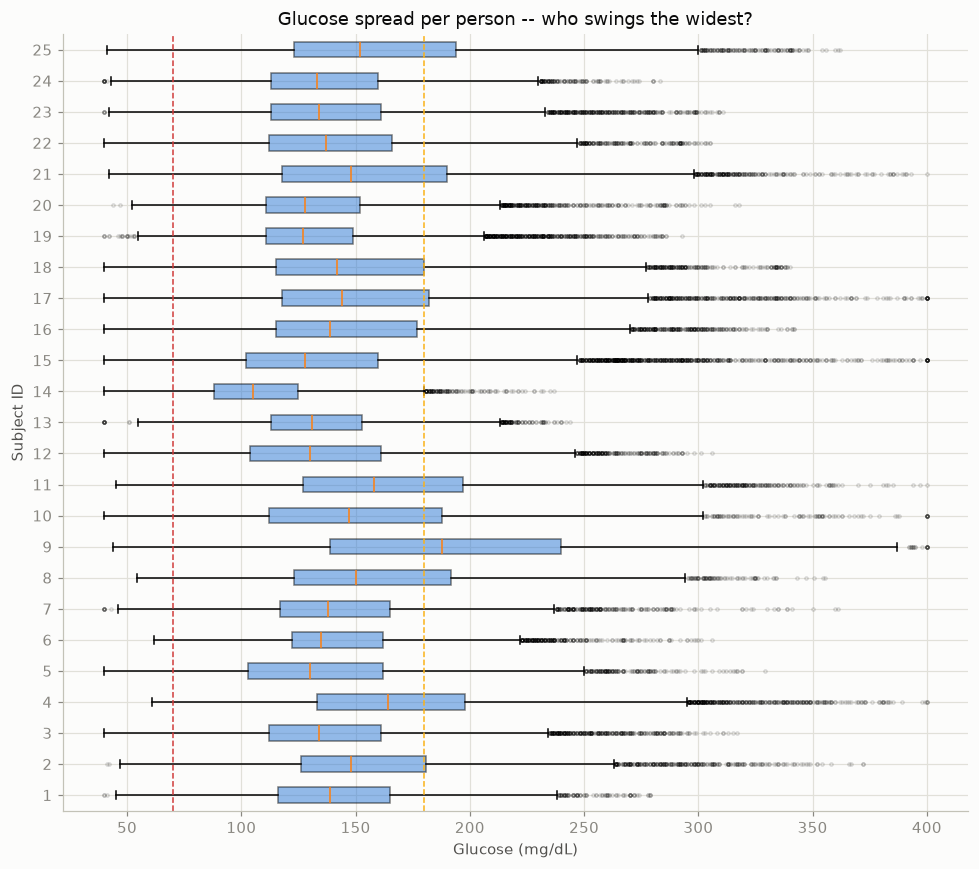

In [10]:
subject_order = sorted(df["subject_id"].unique())
cgm_by_subject = [df.loc[df["subject_id"] == sid, ref.CGM] for sid in subject_order]

fig, ax = plt.subplots(figsize=(9, 8))
bp = ax.boxplot(cgm_by_subject, vert=False, tick_labels=[str(s) for s in subject_order],
                 patch_artist=True, flierprops=dict(marker="o", markersize=2, alpha=0.15))
for box in bp["boxes"]:
    box.set_facecolor(plotting.CATEGORICAL[0])
    box.set_alpha(0.5)
ax.axvline(ref.HYPO_THRESHOLD, color=plotting.GLUCOSE_BAND_COLORS["hypo"], linestyle="--", linewidth=1)
ax.axvline(ref.HYPER_THRESHOLD, color=plotting.GLUCOSE_BAND_COLORS["hyper"], linestyle="--", linewidth=1)
ax.set_xlabel("Glucose (mg/dL)")
ax.set_ylabel("Subject ID")
ax.set_title("Glucose spread per person -- who swings the widest?")
fig.tight_layout()
plt.show()


That's the general shape of the data. Now let's turn some of these same signals into the
exact inputs the predictor will use.


**Observation:** A few people stand out. Subject 9's average and median glucose are both
above 180, meaning more than half their readings are hyperglycemic, not just some of
them. Worth asking whether that is outside the patient's control (insulin needs, pump
settings) or a matter of daily choices, since the answer changes what kind of
intervention would help. The wider point: every person's box is wide. That
person-to-person and day-to-day variability is the actual difficulty this whole project
is up against.


## 3. What clues does the model get to look at?

For every 5-minute reading, we hand the model six pieces of information: the current
glucose level, how much background insulin is dripping in, how much meal-time insulin was
just given, how many carbs were just eaten, a smoothed-out ~17-hour trend line of glucose
(so it can tell "rising fast" apart from "rising slowly"), and a simple flag for whether
that reading counts as dangerously low, normal, or dangerously high.


In [11]:
example_subject = df[df["subject_id"] == df["subject_id"].iloc[0]].reset_index(drop=True)
enriched = feat.add_engineered_features(example_subject)
print("Feature columns used as model input:", feat.FEATURE_COLUMNS)
print("Target column:", feat.TARGET_COLUMN)
enriched[[ref.EVENT_DATETIME, *feat.FEATURE_COLUMNS]].head()


Feature columns used as model input: ['CGM', 'Basal', 'TotalBolusInsulinDelivered', 'CarbSize', 'cgm_ma200', 'region_label']
Target column: CGM


,EventDateTime,CGM,Basal,TotalBolusInsulinDelivered,CarbSize,cgm_ma200,region_label
0,2023-12-08 00:04:00,151.0,2.2,0.0,0.0,151.00,1
1,2023-12-08 00:09:00,152.0,2.2,0.0,0.0,151.50,1
2,2023-12-08 00:14:00,156.0,2.2,0.0,0.0,153.00,1
3,2023-12-08 00:19:00,158.0,2.2,0.0,0.0,154.25,1
4,2023-12-08 00:24:00,160.0,2.2,0.0,0.0,155.40,1


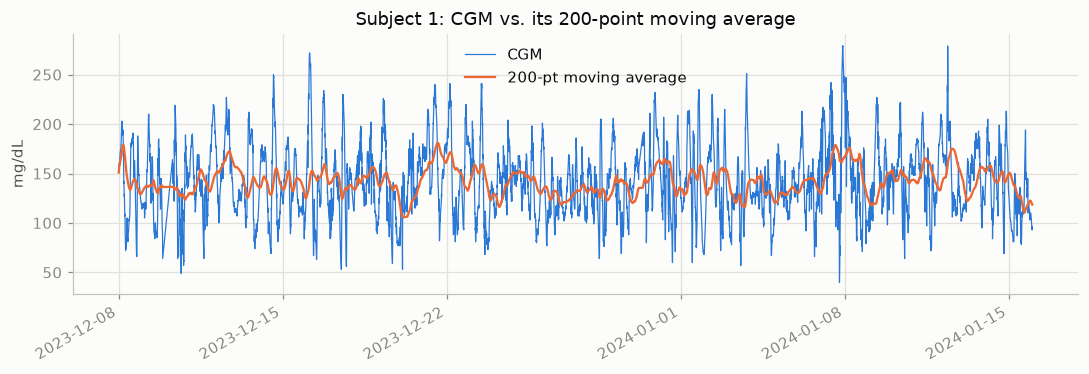

Region label distribution (0=hypo, 1=normal, 2=hyper):
region_label
0     1.1
1    84.4
2    14.4
Name: proportion, dtype: float64


In [12]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(enriched[ref.EVENT_DATETIME], enriched[ref.CGM], color=plotting.CATEGORICAL[0], linewidth=0.8, label="CGM")
ax.plot(enriched[ref.EVENT_DATETIME], enriched[feat.MA_COLUMN], color=plotting.CATEGORICAL[1], linewidth=1.5, label="200-pt moving average")
ax.set_ylabel("mg/dL")
ax.set_title(f"Subject {int(example_subject['subject_id'].iloc[0])}: CGM vs. its 200-point moving average")
ax.legend(frameon=False)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

print("Region label distribution (0=hypo, 1=normal, 2=hyper):")
print(enriched[feat.REGION_COLUMN].value_counts(normalize=True).sort_index().round(3) * 100)


Two of the six clues are worth seeing directly, since they're not raw columns in the data
but things we calculated:

- The orange line above is the same glucose reading, just smoothed over the last ~17
  hours. It tells the model which way things are generally trending, separately from
  the raw, jumpy blue line, so a single noisy spike doesn't get mistaken for a real trend.
- The percentages printed below split this person's time into the three zones (hypo,
  normal, hyper). At every single timestep, the model is also handed a flag for which
  zone that moment falls in, so it always knows not just the glucose number, but whether
  that number counts as dangerous.


## 4. Study material vs. test material

To make one prediction, the model looks at the **last 2 hours** of readings and guesses
what glucose will be **1 hour later**.

To grade it fairly, we do what you'd do with a student: teach using the older data, then
test on data it has never seen before. The most recent stretch of each person's records is
held back purely for grading and is never used for learning.


In [13]:
X, y = seq.make_windows(enriched, feat.FEATURE_COLUMNS, feat.TARGET_COLUMN)
splits = seq.chronological_split(X, y)

print(f"Lookback={seq.LOOKBACK} steps ({seq.LOOKBACK * 5} min), horizon={seq.HORIZON} steps ({seq.HORIZON * 5} min)")
print(f"X shape: {X.shape}  (n_windows, lookback, n_features)")
for split_name in ("X_train", "X_val", "X_test"):
    print(f"  {split_name}: {splits[split_name].shape}")


Lookback=24 steps (120 min), horizon=12 steps (60 min)
X shape: (10846, 24, 6)  (n_windows, lookback, n_features)
  X_train: (6942, 24, 6)
  X_val: (1735, 24, 6)
  X_test: (2169, 24, 6)


## 5. The predictor itself

This is a small, simple pattern-recognizer, nowhere near the size of something like
ChatGPT. It has a few thousand adjustable internal "dials" that get tuned during training
(the original study's version had roughly twice as many). Small enough to train in
seconds per person on an ordinary laptop.


In [14]:
device = get_device()
model = CNNLSTM(n_features=len(feat.FEATURE_COLUMNS))
print(model)
print(f"\nTotal trainable parameters: {count_parameters(model):,}  (paper reports ~10,000)")
print(f"Training device: {device}")


CNNLSTM(
  (conv): Sequential(
    (0): Conv1d(6, 16, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (3): ReLU()
    (4): Conv1d(32, 16, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): ReLU()
  )
  (lstm): LSTM(16, 8, batch_first=True)
  (head): Linear(in_features=8, out_features=1, bias=True)
)

Total trainable parameters: 4,265  (paper reports ~10,000)
Training device: mps


## 6. Trying it on one person first

Before running this on all 25 people, let's train it on just one person and look closely
at how it did: both how its guesses improved with practice, and how its final guesses
line up against what actually happened.


In [15]:
result = train_subject_model(example_subject, epochs=30)

print(f"Subject {result.subject_id}")
print(f"  train/val/test windows: {result.n_train} / {result.n_val} / {result.n_test}")
print(f"  epochs run (early-stopped): {len(result.history)}")
print(f"  RMSE: {result.rmse:.2f} mg/dL   MAE: {result.mae:.2f} mg/dL")


Subject 1
  train/val/test windows: 6942 / 1735 / 2169
  epochs run (early-stopped): 8
  RMSE: 25.29 mg/dL   MAE: 19.51 mg/dL


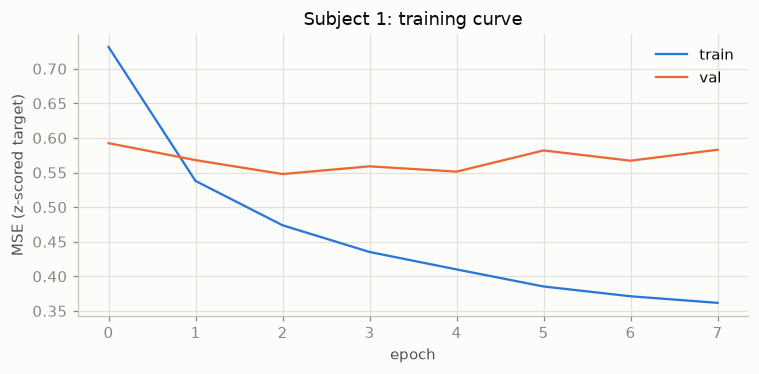

In [16]:
train_losses, val_losses = zip(*result.history)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(train_losses, color=plotting.CATEGORICAL[0], label="train")
ax.plot(val_losses, color=plotting.CATEGORICAL[1], label="val")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE (z-scored target)")
ax.set_title(f"Subject {result.subject_id}: training curve")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


**Observation:** Good catch. Validation error actually rises slightly while training
error keeps falling, which is the classic sign of overfitting. That is exactly what the
early stopping rule watches for: it stops training and keeps the best checkpoint the
moment validation stops improving, instead of letting the model keep memorizing the
training data.


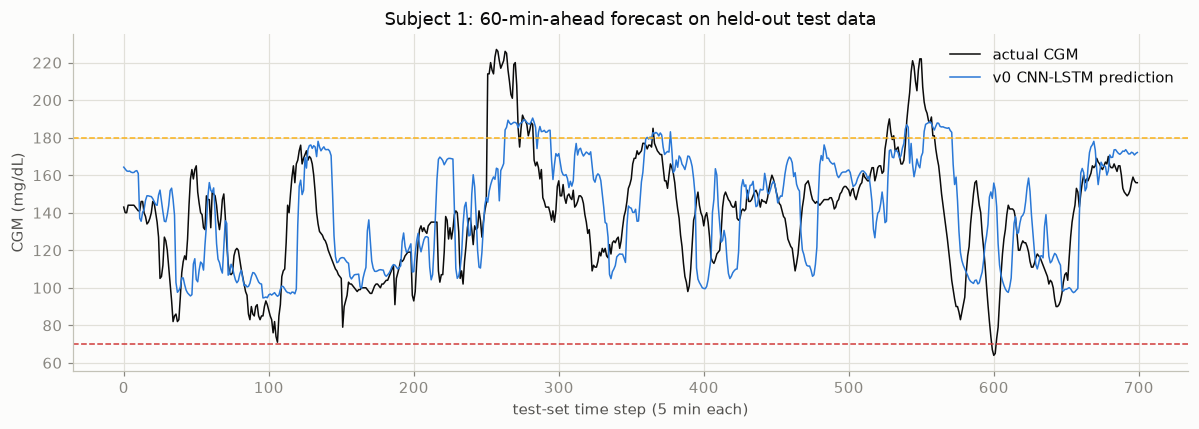

In [17]:
# A representative slice of the test set (paper's Fig. 3 plots ~700 samples ~ 2.4 days).
n_show = min(700, len(result.y_test))
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(result.y_test[:n_show], color=plotting.INK_PRIMARY, linewidth=1, label="actual CGM")
ax.plot(result.y_pred[:n_show], color=plotting.CATEGORICAL[0], linewidth=1, label="v0 CNN-LSTM prediction")
ax.axhline(ref.HYPO_THRESHOLD, color=plotting.GLUCOSE_BAND_COLORS["hypo"], linestyle="--", linewidth=1)
ax.axhline(ref.HYPER_THRESHOLD, color=plotting.GLUCOSE_BAND_COLORS["hyper"], linestyle="--", linewidth=1)
ax.set_xlabel("test-set time step (5 min each)")
ax.set_ylabel("CGM (mg/dL)")
ax.set_title(f"Subject {result.subject_id}: 60-min-ahead forecast on held-out test data"
             + (" (synthetic placeholder data)" if USING_SYNTHETIC else ""))
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


**Observation:** This is the core problem on full display. The predicted line tracks the
actual one fine in the middle of the range, but lags and undershoots right at the sharp
highs and lows, which are the moments that matter most. Closing that gap is exactly what
the paper's real technique (weighting the loss toward those regions) is meant to do.


## 7. Now for everyone

Same process, repeated for all 25 people. Each person gets their own personal predictor,
since everyone's body responds to food and insulin a little differently. This only takes
about 5 minutes total to run.


In [18]:
summary, results = run_baseline_v0(df, epochs=30)
summary


,rmse,mae,n_test
subject_id,,,
1,25.286068,19.510221,2169
2,36.729267,27.283310,2231
3,24.959923,18.575418,2130
4,32.118347,24.561123,2543
5,26.973818,21.182436,2603
6,24.889729,17.932789,2539
7,27.974859,20.299192,2670
8,35.176613,26.279772,1601
9,33.083672,25.677402,2128


## 8. How close did we get to the original study?

The original researchers reported that their basic (non-clever) version was off by
roughly 30 mg/dL on average per guess. Our version, built from scratch with several
guessed settings and no access to their original code, comes out close to that same
range. That's a good sign the overall approach holds together before we add the paper's
actual innovation on top.


In [19]:
print(f"v0 CNN-LSTM baseline ({'synthetic' if USING_SYNTHETIC else 'real'} AZT1D, n={len(summary)} subjects)")
print(f"  RMSE: {summary['rmse'].mean():.2f} +/- {summary['rmse'].std():.2f} mg/dL")
print(f"  MAE:  {summary['mae'].mean():.2f} +/- {summary['mae'].std():.2f} mg/dL")
print()
print("Paper's CNN-LSTM baseline on AZT1D: RMSE 29.55 +/- 6.49 mg/dL, MAE 21.61 +/- 5.19 mg/dL")
print("Paper's CNN-LSTM baseline on OhioT1DM: RMSE 31.98 +/- 4.15 mg/dL, MAE 23.00 +/- 2.87 mg/dL")


v0 CNN-LSTM baseline (real AZT1D, n=25 subjects)
  RMSE: 31.54 +/- 6.22 mg/dL
  MAE:  24.01 +/- 5.11 mg/dL

Paper's CNN-LSTM baseline on AZT1D: RMSE 29.55 +/- 6.49 mg/dL, MAE 21.61 +/- 5.19 mg/dL
Paper's CNN-LSTM baseline on OhioT1DM: RMSE 31.98 +/- 4.15 mg/dL, MAE 23.00 +/- 2.87 mg/dL


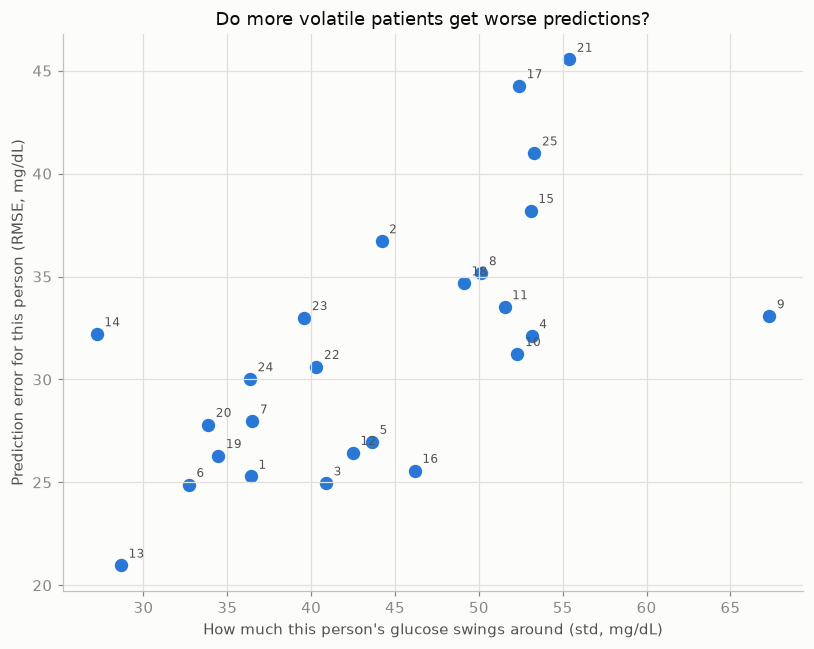

Correlation between a person's glucose variability and their prediction error: 0.64


In [20]:
# Does this person's day-to-day glucose variability predict how hard they are to forecast?
subject_variability = df.groupby("subject_id")[ref.CGM].std().rename("cgm_std")
combined = summary.join(subject_variability)

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.scatter(combined["cgm_std"], combined["rmse"], color=plotting.CATEGORICAL[0], s=60)
for sid, row in combined.iterrows():
    ax.annotate(str(sid), (row["cgm_std"], row["rmse"]), fontsize=8, xytext=(5, 5),
                textcoords="offset points", color=plotting.INK_SECONDARY)
ax.set_xlabel("How much this person's glucose swings around (std, mg/dL)")
ax.set_ylabel("Prediction error for this person (RMSE, mg/dL)")
ax.set_title("Do more volatile patients get worse predictions?"
             + (" (synthetic placeholder data)" if USING_SYNTHETIC else ""))
fig.tight_layout()
plt.show()

link = combined["cgm_std"].corr(combined["rmse"])
print(f"Correlation between a person's glucose variability and their prediction error: {link:.2f}")


The chart above swaps a plain per-subject ranking for a more useful question, following
up on the earlier observation that variability is "the problem and the difficulty": does
someone with a more erratic glucose pattern actually get worse predictions? A positive
correlation says yes: the model struggles most exactly where the person's own glucose is
hardest to predict in the first place, not from random noise.


## 9. What's next

- **Next up:** teach the model to care more about dangerous highs and lows specifically,
  instead of just being right on average. This is the actual idea from the paper.
- **After that:** check not just how far off the numbers were, but how often this would
  have missed a dangerous moment. A more clinically meaningful way to judge it.
- **Down the line:** let the computer automatically search for the best settings instead
  of us guessing, and try a second, more complex model type, to fully match what the
  original paper did.

Once real data is flowing through this consistently, it's also worth double-checking a
couple of the guesses we made early on, like exactly how far back the model looks before
making a guess.
